# 01 · Noisy-OR MIL

Pool data0 + data1 + data2 and group observations by shared human gene or synthetic construct.
This notebook supports an independent **Restart Kernel and Run All** without running other AdvancedModel notebooks first.
Outputs are written to `data/processed/advanced/runs/noisy_or/<run_id>/`.

Encode each read's signals and three adjacent 5-mers, then use `1 − ∏(1 − p_read)` to produce a site score.
This is a project-specific adaptation inspired by m6Anet, **not a reproduction of the original implementation or the official benchmark**:
feature transformations, network widths, and training procedures differ.
Noisy-OR uses a numerically stable log-survival calculation. Short bags use masks without duplicating reads.
Predictions can still depend on the number of valid reads, so coverage is retained and the sampling limit is fixed.

**Architecture:** `Read signals + k-mer embedding → shared MLP → read logits → Noisy-OR → site score`

[Architecture reference](https://www.nature.com/articles/s41592-022-01666-1) · Shared implementation: `common/models.py` · Data: `common/data.py`


## 1. Environment

From the repository root, run `source .venv/bin/activate` and `python -m pip install -r requirements.txt`,
then select the `.venv` kernel in VS Code. All three `data/processed/annotated/dataN_reads.parquet` files are required.
If they are missing, run `python -m scripts.prepare_datasets --download` first.
This notebook does not install dependencies or download data automatically.


In [1]:
from pathlib import Path
import sys
import json

ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / 'src/modelling_data.py').is_file()), None)
if ROOT is None:
    raise FileNotFoundError('Open this notebook from the repository root or AdvancedModel/ directory.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display
from AdvancedModel.common.data import prepare_store
from AdvancedModel.common.models import MILModel, ModelConfig
from AdvancedModel.common.training import (
    TrainConfig, resolve_device, create_run, run_grouped_cv, fit_final,
    predict_bags, save_mil_bundle, load_mil_bundle, mark_complete,
)
from AdvancedModel.common.evaluation import (
    select_threshold, metric_report, save_evaluation, plot_evaluation,
)
print('Project:', ROOT)
print('PyTorch:', torch.__version__)


Project: /Users/jiacheng/Documents/GitHub/DSA4262_Genomies
PyTorch: 2.9.1


## 2. Experiment configuration

`device='auto'` selects CUDA, Apple MPS, or CPU, in that order; you can also select a device explicitly.
All models use the same default read limit, CV folds, and training budget. Configuration changes define a new experiment.
`max_epochs` caps inner early-stopping training; training CV determines the final epoch count.
The auxiliary mixture-fraction task is disabled by default. If enabled, record it as a separate experiment and compare it with the disabled setting.


In [2]:
# ---------- Main settings: select the device for your first run ----------
PROCESSED_DIR = ROOT / 'data/processed'
SPLIT_SEED = 42
CV_FOLDS = 5
BOOTSTRAP_REPEATS = 500

# If a pooled H04 run exists, verify identical sources, splits, and CV folds.
REFERENCE_RUN = ROOT / 'data/processed/modelling/pooled_data0_data1_data2_group_split_seed42/person_c_runs/20261006T085253_d868f3c6'
if not REFERENCE_RUN.is_dir():
    REFERENCE_RUN = None  # A fresh checkout can prepare inputs directly from annotated files

MODEL = ModelConfig(
    architecture='noisy_or', embedding_dim=8, hidden_dim=128,
    read_dim=64, attention_dim=64, dropout=0.1, heads=4, set_layers=2,
)
TRAIN = TrainConfig(
    seed=42, device='auto', threads=4, batch_size=128, max_reads=32,
    max_epochs=25, patience=4, learning_rate=1e-3, weight_decay=1e-4,
    gradient_clip=5.0, predict_draws=5, inner_stop_fraction=0.15,
    dataset_weights=(1.0, 1.0, 1.0),  # Order: data0, data1, data2
    auxiliary_weight=0.0,           # >0 enables auxiliary regression on original data2 mixture fractions
    positive_weight='none',         # none / ratio / sqrt_ratio; computed from current fitting labels only
)
NOTEBOOK_PATH = ROOT / 'AdvancedModel/01_noisy_or_mil.ipynb'
print('Device:', resolve_device(TRAIN.device))
print('Reference run:', REFERENCE_RUN)


Device: mps
Reference run: /Users/jiacheng/Documents/GitHub/DSA4262_Genomies/data/processed/modelling/pooled_data0_data1_data2_group_split_seed42/person_c_runs/20261006T085253_d868f3c6


## 3. Data validation, shared splits, and read cache

Store all nine measurements per read, applying log transformation to dwell times, and build a site index for random access.
Normalization is not fitted on the complete dataset. Each fitting partition estimates the means and standard deviations
for its adjacent 5-mers from its own reads. Unseen 5-mers use that fitting partition's statistics for the corresponding position.
The first run creates approximately 0.72 GB of read arrays plus metadata; subsequent notebooks reuse the same cache.
Short bags use masks. Long bags are sampled without replacement each epoch, and evaluation averages repeated deterministic samples.


In [3]:
store = prepare_store(PROCESSED_DIR, seed=SPLIT_SEED, cv_folds=CV_FOLDS,
                      reference_run=REFERENCE_RUN)
summary = store.sites.groupby(['dataset', 'split']).agg(
    sites=('label', 'size'), groups=('group_id', 'nunique'),
    reads=('n_reads', 'sum'), positive_rate=('label', 'mean'),
)
display(summary)
display(store.sites.query("split == 'train'").groupby(['assessment_fold', 'dataset']).size().unstack(fill_value=0))
print('Read cache:', store.cache_dir)
print('Same human gene / synthetic construct cannot cross partitions or assessment folds.')


Cache data0: 199,568 reads
Cache data0: 399,828 reads
Cache data0: 599,724 reads
Cache data0: 799,940 reads
Cache data0: 999,651 reads
Cache data0: 1,199,999 reads
Cache data0: 1,399,953 reads
Cache data0: 1,599,205 reads
Cache data0: 1,799,994 reads
Cache data0: 1,999,997 reads
Cache data0: 2,199,852 reads
Cache data0: 2,399,900 reads
Cache data0: 2,599,992 reads
Cache data0: 2,799,917 reads
Cache data0: 2,999,962 reads
Cache data0: 3,199,997 reads
Cache data0: 3,399,973 reads
Cache data0: 3,599,998 reads
Cache data0: 3,799,954 reads
Cache data0: 3,999,231 reads
Cache data0: 4,199,905 reads
Cache data0: 4,399,792 reads
Cache data0: 4,599,977 reads
Cache data0: 4,799,939 reads
Cache data0: 4,999,965 reads
Cache data0: 5,199,961 reads
Cache data0: 5,399,993 reads
Cache data0: 5,599,996 reads
Cache data0: 5,799,858 reads
Cache data0: 5,999,895 reads
Cache data0: 6,199,979 reads
Cache data0: 6,399,970 reads
Cache data0: 6,599,892 reads
Cache data0: 6,799,966 reads
Cache data0: 6,999,993 r

sites  groups    reads  positive_rate
dataset split                                       
data0   test   18937     581  1640263       0.044199
        train  85166    2696  7765313       0.045147
        val    17735     575  1621530       0.044714
data1   test   13577     473  1195744       0.076600
        train  63568    2196  5555131       0.072222
        val    13665     480  1157077       0.070399
data2   test     252       1   233268       0.857143
        train    742       2   622952       0.857143
        val      329       1   315720       0.857143

dataset,data0,data1,data2
assessment_fold,,,
1,17986,13562,399
2,15662,12236,0
3,17002,12617,343
4,17227,12593,0
5,17289,12560,0


Read cache: /Users/jiacheng/Documents/GitHub/DSA4262_Genomies/data/processed/advanced/cache/c501339a55eba5e4371a
Same human gene / synthetic construct cannot cross partitions or assessment folds.


## 4. Inspect the model and create an experiment directory

The next cell initializes the network; training starts in the following section.
Each complete run creates a new directory, preserving earlier models and reports.


In [4]:
preview_model = MILModel(MODEL)
print(preview_model)
print('Specification:', preview_model.specification())
del preview_model
RUN_DIR = create_run(store, MODEL, TRAIN, notebook_path=NOTEBOOK_PATH)
print('Run directory:', RUN_DIR)


MILModel(
  (kmer_embedding): Embedding(1024, 8)
  (read_encoder): Sequential(
    (0): Linear(in_features=39, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (6): GELU(approximate='none')
  )
  (set_encoder): ModuleList()
  (read_head): Linear(in_features=64, out_features=1, bias=True)
  (fraction_head): Linear(in_features=64, out_features=1, bias=True)
)
Specification: {'architecture': 'noisy_or', 'embedding_dim': 8, 'hidden_dim': 128, 'read_dim': 64, 'attention_dim': 64, 'dropout': 0.1, 'heads': 4, 'set_layers': 2, 'parameters': 22082}
Run directory: /Users/jiacheng/Documents/GitHub/DSA4262_Genomies/data/processed/advanced/runs/noisy_or/20261006T100745_83bb5109


## 5. Grouped CV within the outer training partition

Keep each assessment fold separate. Within the remaining training groups, create an inner fitting partition and an early-stopping partition.
Fit normalization only on the inner fitting reads, select the epoch count using inner stopping AP, and discard those model weights.
Then refit normalization and train from scratch on **all fold-fitting sites** for the selected number of epochs before evaluating the assessment fold.
The default five folds therefore require **10 neural-network fits**, followed by one final fit on the complete outer training partition.

Outer validation and test data do not participate in early stopping. `cv_mean_sd.csv` reports five-fold mean and sample standard deviation.
Per-dataset OOF metrics aggregate available OOF predictions rather than averaging five folds: data2 has only two training constructs and covers at most two assessment folds.
Rerunning this section in the same run directory is rejected. Running all cells from the configuration section creates a new run directory.


In [5]:
cv = run_grouped_cv(store, MODEL, TRAIN, RUN_DIR)
display(cv.fold_metrics)
display(cv.fold_metrics[['average_precision', 'roc_auc', 'pr_auc_trapezoid']].agg(['mean', 'std']))
display(pd.read_csv(RUN_DIR / 'cv_oof_metrics_by_dataset.csv'))


Fold 1: select epoch count using inner training groups
Epoch 01: loss=0.1588 | inner AP=0.4248
Epoch 02: loss=0.1513 | inner AP=0.4258
Epoch 03: loss=0.1489 | inner AP=0.4314
Epoch 04: loss=0.1475 | inner AP=0.4281
Epoch 05: loss=0.1473 | inner AP=0.4256
Epoch 06: loss=0.1463 | inner AP=0.4361
Epoch 07: loss=0.1455 | inner AP=0.4403
Epoch 08: loss=0.1448 | inner AP=0.4255
Epoch 09: loss=0.1440 | inner AP=0.4400
Epoch 10: loss=0.1435 | inner AP=0.4298
Epoch 11: loss=0.1437 | inner AP=0.4380
Fold 1: refit on all fitting groups for 7 epochs
Epoch 01: loss=0.1667
Epoch 02: loss=0.1589
Epoch 03: loss=0.1563
Epoch 04: loss=0.1557
Epoch 05: loss=0.1547
Epoch 06: loss=0.1537
Epoch 07: loss=0.1529
Fold 1: held-out AP=0.5008
Fold 2: select epoch count using inner training groups
Epoch 01: loss=0.1737 | inner AP=0.4378
Epoch 02: loss=0.1629 | inner AP=0.4535
Epoch 03: loss=0.1607 | inner AP=0.4530
Epoch 04: loss=0.1590 | inner AP=0.4454
Epoch 05: loss=0.1575 | inner AP=0.4596
Epoch 06: loss=0.156

,fold,epochs,fit_sites,assessment_sites,fit_groups,assessment_groups,roc_auc,average_precision,pr_auc_trapezoid
0,1,7,117529,31947,2513,629,0.887364,0.500759,0.500489
1,2,5,121578,27898,2513,629,0.866542,0.377316,0.376623
2,3,9,119514,29962,2514,628,0.851778,0.397733,0.397133
3,4,6,119656,29820,2514,628,0.868183,0.415478,0.415075
4,5,8,119627,29849,2514,628,0.866338,0.423660,0.423038


,average_precision,roc_auc,pr_auc_trapezoid
mean,0.422989,0.868041,0.422472
std,0.046981,0.012679,0.047132


,dataset,sites,groups,positives,positive_rate,metric_status,prior_ap_reference,always_positive_f1,roc_auc,average_precision,pr_auc_trapezoid,assessment_folds
0,pooled,149476,3142,9072,0.060692,ok,0.060692,0.114439,0.868670,0.424459,0.424315,5
1,data0,85166,2696,3845,0.045147,ok,0.045147,0.086394,0.919837,0.484276,0.483990,5
2,data1,63568,2196,4591,0.072222,ok,0.072222,0.134714,0.830095,0.372599,0.372374,5
3,data2,742,2,636,0.857143,ok,0.857143,0.923077,0.827608,0.965325,0.965259,2


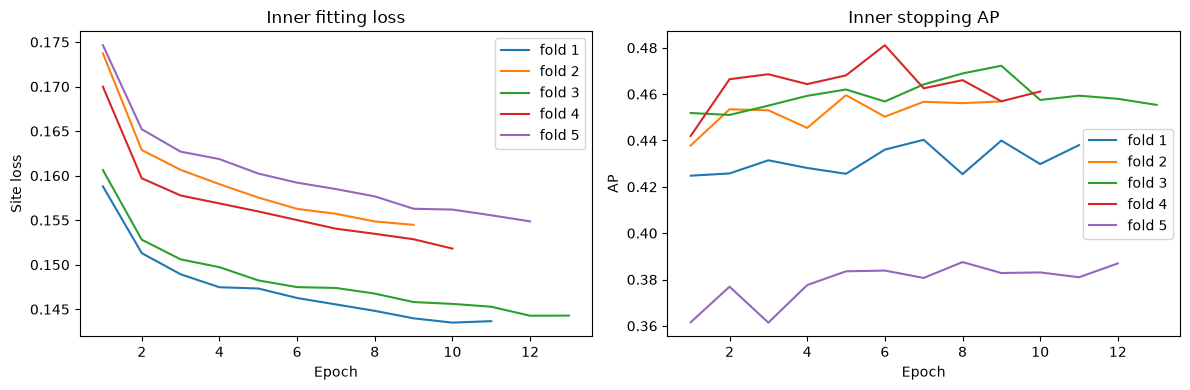

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for fold, history in cv.history.query("phase == 'inner_stop'").groupby('fold'):
    axes[0].plot(history.epoch, history.training_loss, label=f'fold {fold}')
    axes[1].plot(history.epoch, history.inner_stop_ap, label=f'fold {fold}')
axes[0].set(title='Inner fitting loss', xlabel='Epoch', ylabel='Site loss')
axes[1].set(title='Inner stopping AP', xlabel='Epoch', ylabel='AP')
for ax in axes:
    ax.legend()
fig.tight_layout()
fig.savefig(RUN_DIR / 'training_curves.png', dpi=150)
plt.show()


## 6. Lock the epoch count and refit on all outer training data

Use the median of the five folds' selected epoch counts. Refit normalization on outer training reads and train the final model from scratch.
Keep outer validation separate so that threshold selection uses the same fitted model and score distribution as the final evaluation.


In [7]:
model, normalizer, final_epochs = fit_final(store, MODEL, TRAIN, cv, RUN_DIR)
print('Final training epochs:', final_epochs)


Epoch 01: loss=0.1690
Epoch 02: loss=0.1616
Epoch 03: loss=0.1595
Epoch 04: loss=0.1584
Epoch 05: loss=0.1573
Epoch 06: loss=0.1563
Epoch 07: loss=0.1555
Final training epochs: 7


## 7. Validation: select one shared threshold

The model and epoch count are fixed. Maximize validation F1, choosing the larger threshold when tied.
All datasets share this threshold. Architecture selection and training changes are already complete.


In [8]:
val_ids = store.ids('val')
val_scores = predict_bags(model, normalizer, store, val_ids, TRAIN)
threshold, threshold_search = select_threshold(store.sites.iloc[val_ids].label, val_scores)
threshold_search.to_csv(RUN_DIR / 'validation_threshold_search.csv', index=False)
display(metric_report(store.sites.iloc[val_ids], val_scores, threshold))
print('Locked validation threshold:', threshold)


,dataset,sites,groups,positives,positive_rate,metric_status,prior_ap_reference,always_positive_f1,roc_auc,average_precision,...,precision,recall,f1,accuracy,balanced_accuracy,specificity,tn,fp,fn,tp
0,pooled,31729,674,2037,0.064200,ok,0.064200,0.120654,0.868836,0.457657,...,0.468670,0.536082,0.500114,0.931199,0.747194,0.958305,28454,1238,945,1092
1,data0,17735,575,793,0.044714,ok,0.044714,0.085600,0.924981,0.506040,...,0.423673,0.654477,0.514371,0.944742,0.806403,0.958328,16236,706,274,519
2,data1,13665,480,962,0.070399,ok,0.070399,0.131538,0.826423,0.388824,...,0.457143,0.465696,0.461380,0.923454,0.711908,0.958120,12171,532,514,448
3,data2,329,1,282,0.857143,ok,0.857143,0.923077,0.884639,0.980140,...,1.000000,0.443262,0.614251,0.522796,0.721631,1.000000,47,0,157,125


Locked validation threshold: 0.2147938497364521


## 8. Test: pooled and per-dataset evaluation

Score the test partition after fixing the threshold. Save AP, ROC-AUC, trapezoidal PR-AUC, precision, recall, F1,
confusion matrices, and per-site predictions. These datasets were explored in earlier project work, so this is an internal evaluation.


,dataset,sites,groups,positives,positive_rate,metric_status,prior_ap_reference,always_positive_f1,roc_auc,average_precision,...,precision,recall,f1,accuracy,balanced_accuracy,specificity,tn,fp,fn,tp
0,pooled,32766,674,2093,0.063877,ok,0.063877,0.120084,0.871619,0.445374,...,0.460720,0.537984,0.496363,0.930263,0.747507,0.957031,29355,1318,967,1126
1,data0,18937,581,837,0.044199,ok,0.044199,0.084657,0.923902,0.491054,...,0.422783,0.660693,0.515618,0.945134,0.809490,0.958287,17345,755,284,553
2,data1,13577,473,1040,0.076600,ok,0.076600,0.142300,0.832805,0.397824,...,0.459693,0.460577,0.460134,0.917213,0.707835,0.955093,11974,563,561,479
3,data2,252,1,216,0.857143,ok,0.857143,0.923077,0.869599,0.976813,...,1.000000,0.435185,0.606452,0.515873,0.717593,1.000000,36,0,122,94


,estimate,lower_95,upper_95
average_precision,0.445374,0.405016,0.491779
roc_auc,0.871619,0.858152,0.884801
f1,0.496363,0.463420,0.531716


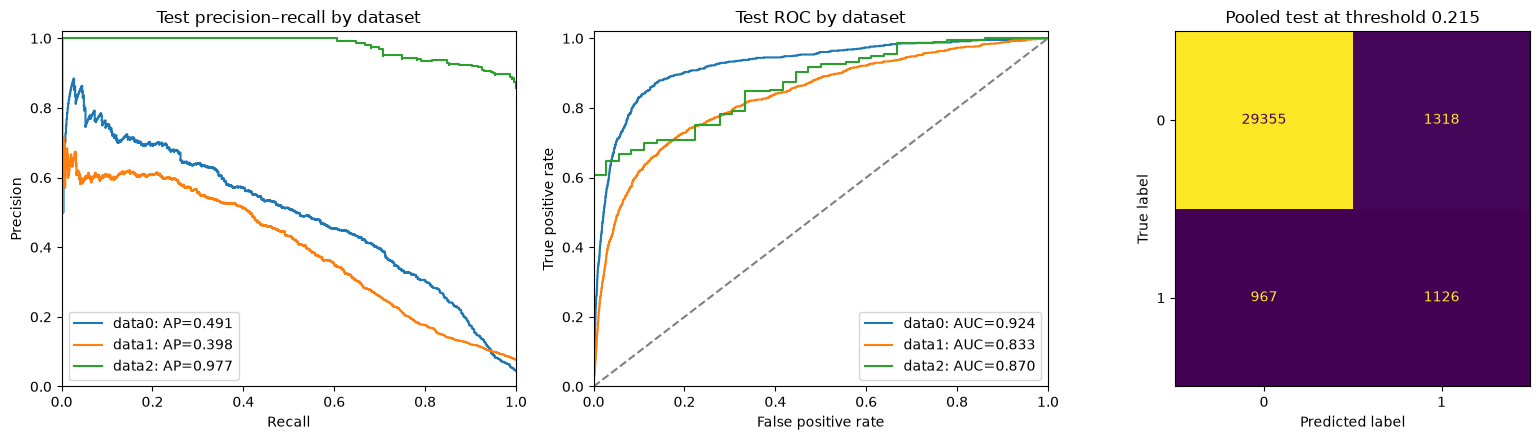

In [9]:
test_ids = store.ids('test')
test_scores = predict_bags(model, normalizer, store, test_ids, TRAIN)
reports = save_evaluation(store, val_scores, test_scores, threshold, RUN_DIR,
                          bootstrap_repeats=BOOTSTRAP_REPEATS)
display(reports['test'], reports['intervals'])
plot_evaluation(store.sites.iloc[test_ids], test_scores, threshold, RUN_DIR / 'test_curves.png')
plt.show()


## 9. Save and verify a reloadable model

The checkpoint contains the architecture configuration, state_dict, k-mer normalization parameters, sampling configuration, threshold, and data fingerprint.
After reloading, compare predictions on a validation subset. Write `complete.json` only after this check succeeds.


In [10]:
save_mil_bundle(RUN_DIR / 'model.pt', model, normalizer, TRAIN, store,
                threshold=threshold, epochs=final_epochs)
restored, restored_normalizer, restored_config, bundle = load_mil_bundle(
    RUN_DIR / 'model.pt', device=str(resolve_device(TRAIN.device)))
check_ids = val_ids[:min(128, len(val_ids))]
restored_scores = predict_bags(restored, restored_normalizer, store, check_ids, restored_config)
np.testing.assert_allclose(restored_scores, val_scores[:len(check_ids)], rtol=1e-4, atol=1e-6)
assert bundle['threshold'] == threshold
mark_complete(RUN_DIR, architecture=MODEL.architecture, threshold=threshold, epochs=final_epochs)
print('PASS: checkpoint reload verified.')
print('Complete run:', RUN_DIR)


PASS: checkpoint reload verified.
Complete run: /Users/jiacheng/Documents/GitHub/DSA4262_Genomies/data/processed/advanced/runs/noisy_or/20261006T100745_83bb5109


## 10. Interpreting the results

- Use training CV AP for model comparison and selection; avoid repeatedly selecting models from test results.
- Examine AP, precision, and recall separately for data0 and data1. Larger datasets contribute more to pooled AP.
- data2 predicts positive mixtures, has a high positive prevalence, and has only one held-out test construct.
  Reports include `prior_ap_reference` and `always_positive_f1` to put high AP and F1 values in context.
- Bootstrap sampling resamples whole groups within human and synthetic strata. The single test construct remains fixed in every draw,
  so these intervals **cannot quantify generalization uncertainty across synthetic constructs**. They also exclude training and model-selection uncertainty.
- Repeated read samples are determined by the seed, site identity, and draw number. Training on different devices is not guaranteed to be bitwise identical.
- Dataset identity, gene ID, construct ID, and label_original are not classification inputs.
  If the auxiliary loss is enabled, only training data2 label_original values provide auxiliary supervision.
